In [1]:
import numpy as np

def load_rowland_sessions(npz_path):
    """Load sessions from the exported .npz file."""
    data = np.load(npz_path, allow_pickle=True)
    session_ids = data['session_ids']
    
    sessions = {}
    for sid in session_ids:
        prefix = f"session_{sid}_"
        sessions[sid] = {
            'signature': str(data[f'{prefix}signature']),
            'mouse': str(data[f'{prefix}mouse']),
            'run_number': int(data[f'{prefix}run_number']),
            'name': str(data[f'{prefix}name']),
            'filter_ps_time': data[f'{prefix}filter_ps_time'],
            'behaviour_trials': data[f'{prefix}behaviour_trials'],
            'is_target': data[f'{prefix}is_target'],
            'trial_subsets': data[f'{prefix}trial_subsets'],
            'n_cells': int(data[f'{prefix}n_cells']),
            'n_trials': int(data[f'{prefix}n_trials']),
            'n_times': int(data[f'{prefix}n_times']),
            's1_bool': data[f'{prefix}s1_bool'],
            's2_bool': data[f'{prefix}s2_bool'],
            'outcome': data[f'{prefix}outcome'],
            'frequency': float(data[f'{prefix}frequency']),
        }
    return sessions

sessions=load_rowland_sessions('/home/patriciobarber/AdaptiveLatents/workspace/datasets/rowland23/all_sessions.npz')

s0 = sessions[0]

In [2]:
# --- CORRECTION OF TIMING ---
# Shift timing so that t=0 is one timepoint earlier
time_axis = s0['filter_ps_time']
dt = time_axis[1] - time_axis[0]
print(f"Original Time Range: {time_axis.min():.4f} to {time_axis.max():.4f}")

# The user wants the current index for 0 to now be +dt (or rather, the index -1 is the new 0).
# If correct t=0 is one timepoint BEFORE current t=0:
# Current: ... t[-1]=-dt, t[0]=0, t[1]=dt ...
# New:     ... t[-1]=0,   t[0]=dt, ... (This shifts time array to the right? No.)

# "stimulus onset 1 timepoint before before what is currently indicated"
# Current 0 is at index `zero_idx`.
# We want index `zero_idx - 1` to be the new 0.
# So we need to ADD `dt` to the time axis? 
# If t[zero_idx] = 0, and we want t[zero_idx-1] = 0.
# Currently t[zero_idx-1] = -dt. 
# To make it 0, we add dt. 
# Then t[zero_idx] becomes dt.

s0['filter_ps_time'] = s0['filter_ps_time'] + dt
time_axis = s0['filter_ps_time']
zero_idx = np.argmin(np.abs(time_axis))

print(f"Corrected Time Range: {time_axis.min():.4f} to {time_axis.max():.4f}")
print(f"New Stimulus Onset Index: {zero_idx}, Time: {time_axis[zero_idx]:.4f}s")

Original Time Range: -7.9667 to 6.0000
Corrected Time Range: -7.9333 to 6.0333
New Stimulus Onset Index: 238, Time: -0.0000s


behaviour_trials shape: (471, 162, 420)


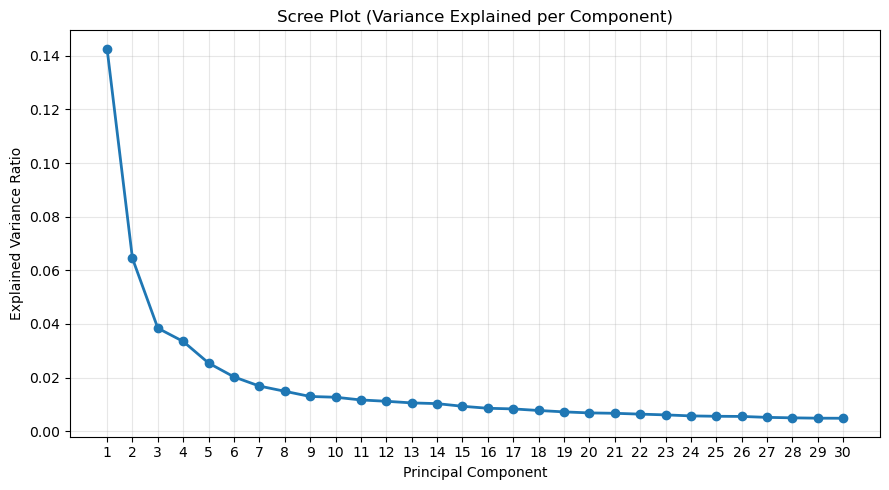

Samples used: 68040, Features (cells): 471
First 10 explained variance ratios:
[0.1426 0.0644 0.0384 0.0335 0.0254 0.0203 0.0169 0.0149 0.013  0.0127]


In [3]:
import matplotlib.pyplot as plt

# Pull trial data from the session and convert to a clean numeric array.
X_raw = np.asarray(s0['behaviour_trials'], dtype=float)
print(f"behaviour_trials shape: {X_raw.shape}")

n_cells = int(s0.get('n_cells', X_raw.shape[-1]))

if X_raw.ndim == 3:
    # Flatten non-cell axes into observations, keep cells as features.
    candidate_axes = [i for i, d in enumerate(X_raw.shape) if d == n_cells]
    cell_axis = candidate_axes[0] if candidate_axes else 1
    X = np.moveaxis(X_raw, cell_axis, -1).reshape(-1, n_cells)
elif X_raw.ndim == 2:
    if X_raw.shape[1] == n_cells:
        X = X_raw
    elif X_raw.shape[0] == n_cells:
        X = X_raw.T
    else:
        X = X_raw
else:
    raise ValueError(f"Unsupported behaviour_trials dimensionality: {X_raw.ndim}")

# Remove rows with NaN/Inf values so SVD remains stable.
valid_rows = np.isfinite(X).all(axis=1)
X = X[valid_rows]

# Center features (neurons) before PCA.
X_centered = X - X.mean(axis=0, keepdims=True)

# PCA via SVD: eigenvalues are variances explained per component.
_, S, _ = np.linalg.svd(X_centered, full_matrices=False)
explained_variance = (S ** 2) / (X_centered.shape[0] - 1)
explained_variance_ratio = explained_variance / explained_variance.sum()

n_plot = min(30, explained_variance_ratio.size)
components = np.arange(1, n_plot + 1)

plt.figure(figsize=(9, 5))
plt.plot(components, explained_variance_ratio[:n_plot], marker='o', linewidth=2)
plt.xticks(components)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot (Variance Explained per Component)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Samples used: {X_centered.shape[0]}, Features (cells): {X_centered.shape[1]}")
print("First 10 explained variance ratios:")
print(np.round(explained_variance_ratio[:10], 4))

In [4]:
cum30 = explained_variance_ratio[:10].sum()
print(f"Cumulative explained variance (30 PCs): {cum30:.6f} ({cum30*100:.2f}%)")

Cumulative explained variance (30 PCs): 0.382101 (38.21%)


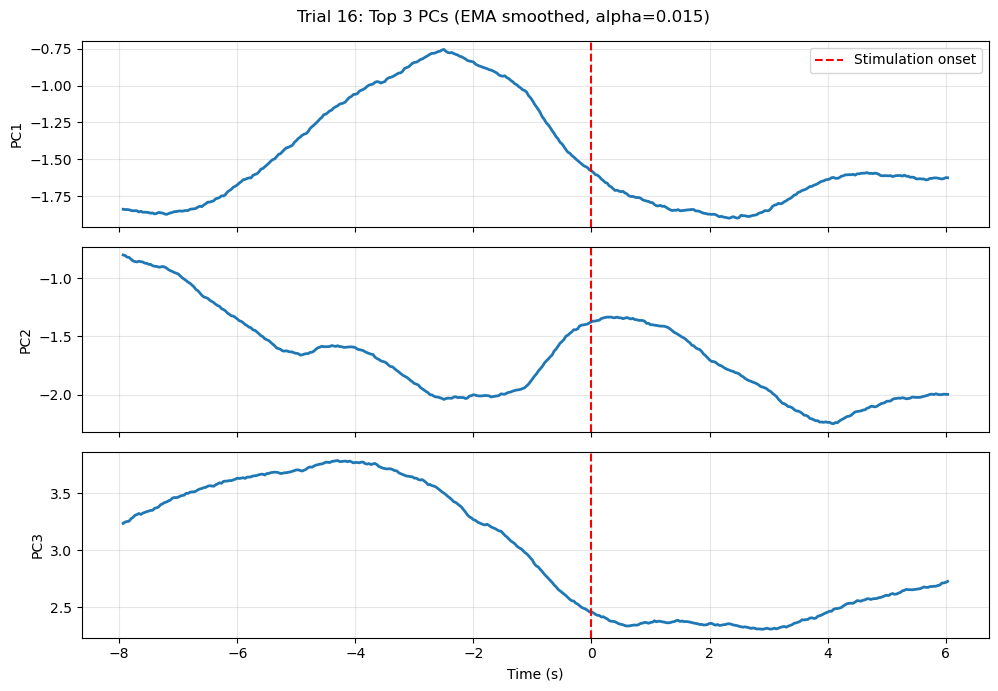

In [14]:
import matplotlib.pyplot as plt

trial_number = 16         # 1-based trial number
trial_idx = trial_number - 1
ema_alpha = 0.015            # EMA smoothing factor (higher = less smoothing)

X3 = np.asarray(s0['behaviour_trials'], dtype=float)
if X3.ndim != 3:
    raise ValueError(f"Expected 3D behaviour_trials, got shape {X3.shape}")

n_cells_local = int(s0.get('n_cells', X3.shape[-1]))
candidate_axes = [i for i, d in enumerate(X3.shape) if d == n_cells_local]
cell_axis = candidate_axes[0] if candidate_axes else 1
X_cells_last = np.moveaxis(X3, cell_axis, -1)  # (?, ?, cells)

n_trials_expected = int(s0.get('n_trials', -1))
n_times_expected = int(s0.get('n_times', -1))
shape0, shape1, _ = X_cells_last.shape

if shape0 == n_trials_expected and shape1 == n_times_expected:
    X_ttc = X_cells_last  # (trials, times, cells)
elif shape1 == n_trials_expected and shape0 == n_times_expected:
    X_ttc = np.transpose(X_cells_last, (1, 0, 2))
elif shape0 == len(time_axis):
    X_ttc = np.transpose(X_cells_last, (1, 0, 2))
else:
    X_ttc = X_cells_last

if not (0 <= trial_idx < X_ttc.shape[0]):
    raise IndexError(f"trial_number={trial_number} out of range [1, {X_ttc.shape[0]}]")

# Fit PCA on all observations (all trials x all times), centered by feature.
X_all = X_ttc.reshape(-1, X_ttc.shape[-1])
valid_rows = np.isfinite(X_all).all(axis=1)
X_fit = X_all[valid_rows]
feature_mean = X_fit.mean(axis=0, keepdims=True)
X_centered_all = X_fit - feature_mean
_, _, Vt = np.linalg.svd(X_centered_all, full_matrices=False)

# Project trial 17 onto top 3 PCs.
trial_data = X_ttc[trial_idx]  # (times, cells)
trial_filled = np.where(np.isfinite(trial_data), trial_data, feature_mean)
trial_scores = (trial_filled - feature_mean) @ Vt[:3].T  # (times, 3)

# EMA smoothing per PC trace.
def ema_1d(x, alpha=0.2):
    y = np.empty_like(x)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i - 1]
    return y

trial_scores_ema = np.column_stack([ema_1d(trial_scores[:, i], ema_alpha) for i in range(3)])

time = np.asarray(time_axis)
if time.shape[0] != trial_scores_ema.shape[0]:
    time = np.arange(trial_scores_ema.shape[0])
    stim_onset = zero_idx if 0 <= zero_idx < len(time) else 0
else:
    stim_onset = time[zero_idx] if 0 <= zero_idx < len(time) else 0.0

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(time, trial_scores_ema[:, i], linewidth=2)
    ax.axvline(stim_onset, color='red', linestyle='--', linewidth=1.5, label='Stimulation onset')
    ax.set_ylabel(f'PC{i+1}')
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(loc='upper right')

axes[-1].set_xlabel('Time (s)' if len(time) == len(time_axis) else 'Time Index')
fig.suptitle(f'Trial {trial_number}: Top 3 PCs (EMA smoothed, alpha={ema_alpha})')
plt.tight_layout()
plt.show()

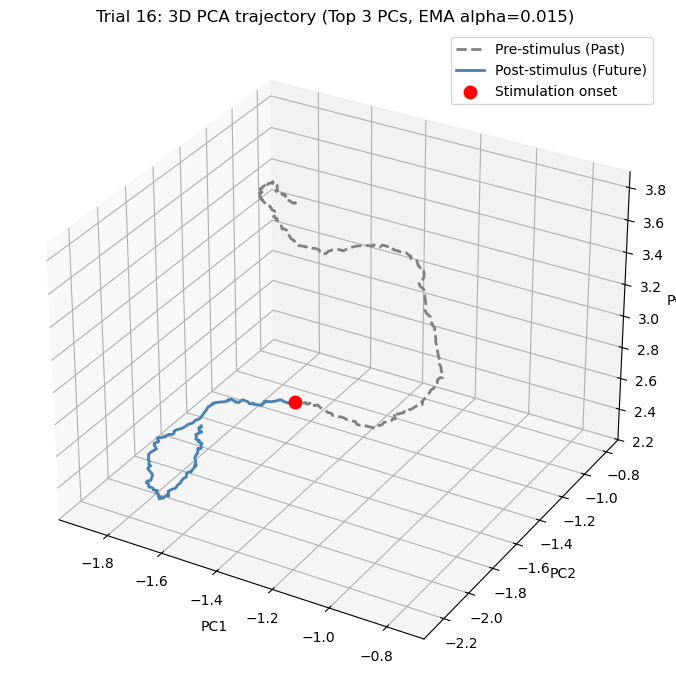

Total distance travelled before stimulation: 4.1057
Total distance travelled after stimulation: 2.1208


In [15]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Explicitly project into top 3 PCs in this cell.
if all(name in globals() for name in ['trial_data', 'feature_mean', 'Vt']):
    trial_filled_local = np.where(np.isfinite(trial_data), trial_data, feature_mean)
    trial_scores_top3 = (trial_filled_local - feature_mean) @ Vt[:3].T
elif 'trial_scores' in globals():
    trial_scores_arr = np.asarray(trial_scores)
    if trial_scores_arr.ndim != 2 or trial_scores_arr.shape[1] < 3:
        raise RuntimeError('trial_scores must be a 2D array with at least 3 components.')
    trial_scores_top3 = trial_scores_arr[:, :3]
else:
    raise RuntimeError('Run Cell 5 first to compute PCA projection inputs.')

# Apply smoothing after projection (post-projection smoothing).
ema_alpha_3d = 0.015

def ema_1d_local(x, alpha=0.2):
    y = np.empty_like(x)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i - 1]
    return y

traj_plot = np.column_stack([ema_1d_local(trial_scores_top3[:, i], ema_alpha_3d) for i in range(3)])

if 'stim_onset' not in globals():
    stim_idx = 0
elif np.isscalar(stim_onset) and np.asarray(time).ndim == 1 and len(time) == traj_plot.shape[0]:
    stim_idx = int(np.argmin(np.abs(np.asarray(time) - stim_onset)))
else:
    stim_idx = int(stim_onset)

stim_idx = int(np.clip(stim_idx, 0, traj_plot.shape[0] - 1))

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Pre-stimulus (Past)
ax.plot(
    traj_plot[:stim_idx+1, 0],
    traj_plot[:stim_idx+1, 1],
    traj_plot[:stim_idx+1, 2],
    color='gray',
    linewidth=2,
    linestyle='--',
    label='Pre-stimulus (Past)'
)

# Post-stimulus (Future)
ax.plot(
    traj_plot[stim_idx:, 0],
    traj_plot[stim_idx:, 1],
    traj_plot[stim_idx:, 2],
    color='steelblue',
    linewidth=2,
    label='Post-stimulus (Future)'
)

ax.scatter(
    traj_plot[stim_idx, 0],
    traj_plot[stim_idx, 1],
    traj_plot[stim_idx, 2],
    color='red',
    s=80,
    label='Stimulation onset'
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title(f'Trial {trial_number}: 3D PCA trajectory (Top 3 PCs, EMA alpha={ema_alpha_3d})')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

# Calculate and print total distance travelled before and after stimulation
dist_before = np.sum(np.linalg.norm(np.diff(traj_plot[:stim_idx+1], axis=0), axis=1))
dist_after = np.sum(np.linalg.norm(np.diff(traj_plot[stim_idx:], axis=0), axis=1))

print(f"Total distance travelled before stimulation: {dist_before:.4f}")
print(f"Total distance travelled after stimulation: {dist_after:.4f}")